# 🧪Lab: Predicting Seismic Building Response with Support Vector Regression

In this lab, you will practice **Support Vector Machine (SVM)** in the context of **regression**. Over the past two weeks, we have focused on SVM for **classification problems**. However, SVM can also be extended to handle **regression tasks**—this is known as **Support Vector Regression (SVR)**.

To explore this, you will work with the following paper:  https://www.nature.com/articles/s41598-024-81705-3

In this paper, the authors use **real seismic monitoring data** to develop an SVR-based model for predicting the **maximum inter-story drift ratio** of buildings during earthquakes. The authors compare a full-feature model with a reduced-feature version, and demonstrate that SVR is effective in this complex, real-world regression setting.

You will begin by reading the **introduction** of the paper to understand the motivation behind the problem. Later, you will apply Support Vector Regression to their dataset.

Reference:

- Tao, D., Fang, S., Liu, H. et al. Support vector regression model for the prediction of buildings’ maximum seismic response based on real monitoring data. Sci Rep 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3

---

**Software**: Use `scikit-learn` and its implementation of Support Vector Regression in this lab. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

---
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [ ]:
# NAME(s) = "DJ, Kayla, Mason"

NAME(s) = DJ, Kayla, Mason

## 1. Paper reflection (10 points) (Mason)

a. After reading the introduction of the paper, discuss within the group and address the following questions: (Mason)
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)

- Why might the NDE1.0 dataset be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).

Please, elaborate on your answers.

Earthquakes can be severly destructive. In the US alone, they account for nearly $15 billion worth of damages per year. Predicting seismic building response is crucial for not only the structural design and choice of materials for a building, but also urban design and emergency planning. With better data-driven insights into seismic building responses, economic losses can be reduced, and most importantly, human lives can be saved.

The NDE1.0 dataset is well suited for this problem for many reasons. First, there are over 10k records in the data, and these records span a variety of building types, including steel frame, reinforced concrete, steel-reinforced concrete, masonry, and even wood. Next, this dataset contains a range of parameters relating the the size, location and structure of the building, attributes about the earthquake itself, and features associated with duration and energy of the earthquake. Traditional physics and mechanical-based methods may fall short because they require detailed inputs and can be computationally expensive, while this dataset allows ML models to account for large numbers of variables simultaneously and uncover complex relationships. A machine learning approach will be useful for finding the most significant variables that affect building response.

b. After reading the paper, explain how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, i.e. what is the intuition behind each equation? (Mason)

Support Vector Regression is a method that has the ability to model nonlinear relationships between variables by applying a nonlinear kernel to the features. It is based on SVMs, but it has the ability to capture relationships that are not linear.
- Formula 1 is similar to a linear regression function, but it applies a fixed feature-space transformation on each variable x.
- Formula 2 is a regularized function that applies a penalty parameter
- Formula 3 defines the epsilon-insensitive loss function, which calculates the error between the predicted values and true values, also considering a tolerance (ignoring error values less than epsilon)
- Formula 4 combines the regulariation function with the penatly term from the slack variables, balancing model flatness with tolerance for error
- Formula 5 sets the constraints, stating that the slack variables are greater than zero and that violations only occur when the difference between the predicted values and true values is smaller than the epsilon margin
- Formula 6 includes the objective function, which is sought to be minimized, and incorporates the Lagrange multipliers as contraints
- Formula 7 calculates a new weight (W) based on Lagrange multipliers and the transformation function
- Formula 8 ensures the sum of the Lagrange multipliers equal zero
- Formula 9 establishes a constant (C) which is two Lagrange multipliers added together- it specifies that the Lagrange multipliers are bounded between 0 and C
- Formula 10 introduces the kernel function into the regression function, allowing observations to be transformed without high-dimensional mapping explicitly being computed
- Formula 11 is the final formula used to predict y based on Lagrance multipliers and using the kernel function to transform observations

## 2. Exploratory Analysis (15 Points)

a. Download the NDE1.0 dataset from [this link](https://www.isterre.fr/annuaire/pages-web-du-personnel/philippe-gueguen/new-earthquake-data-recorded-in-buildings-nde1-0/article/acces-to-the-flatfile.html).

Load the data and display the first few rows. (Kayla and DJ)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer

In [ ]:
# [Your code here]
url = "https://www.isterre.fr/IMG/xlsx/flat_file_nde1.0_march2020.xlsx"

dataset = pd.read_excel(url, header=1, skiprows=[2])

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [ ]:
print(dataset.head())
print(dataset.columns)

  Network Building ID  B_Lat.  B_Long.                  Soil info.   Vs30  \
0     BRI         ANX  36.132  140.073  Sandy clay and clayey sand  200.0   
1     NaN         NaN  36.132  140.073  Sandy clay and clayey sand  200.0   
2     NaN         NaN  36.132  140.073  Sandy clay and clayey sand  200.0   
3     NaN         NaN  36.132  140.073  Sandy clay and clayey sand  200.0   
4     NaN         NaN  36.132  140.073  Sandy clay and clayey sand  200.0   

   Height  No. of story Typology                    Event Date  ...  \
0  3400.0             8      SRC  '199806011635_ANX_BFE_180_1'  ...   
1  3400.0             8      SRC  '199806080802_ANX_BFE_180_1'  ...   
2  3400.0             8      SRC  '199806081648_ANX_BFE_180_1'  ...   
3  3400.0             8      SRC  '199806131315_ANX_BFE_180_1'  ...   
4  3400.0             8      SRC  '199806142217_ANX_BFE_180_1'  ...   

   Uniform [0.15g]  Bracketed [0.2g]  Uniform [0.2g]  \
0              0.0               0.0             0.0  

b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features. (Kayla and DJ)


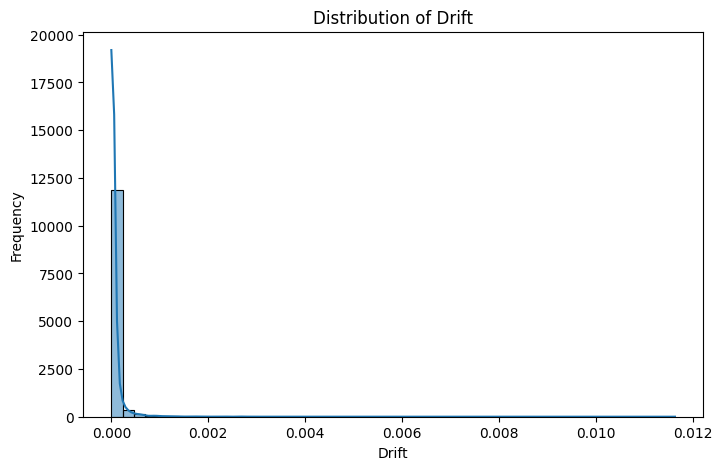

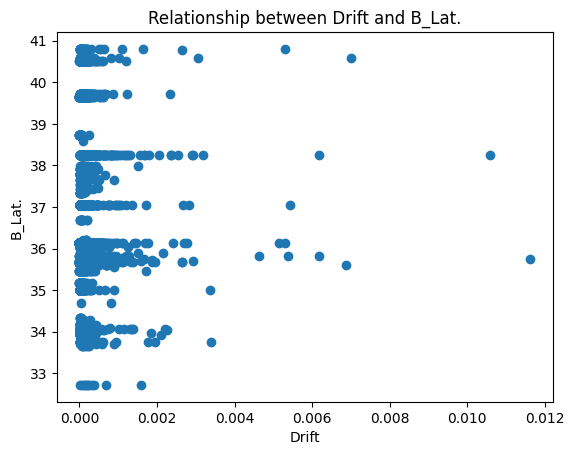

The covariance value between Drift and B_Lat. is -1.0290693246705788e-05 



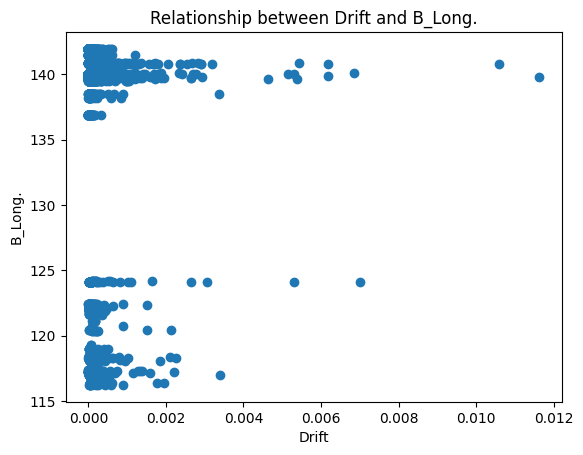

The covariance value between Drift and B_Long. is -0.00012584171986484673 



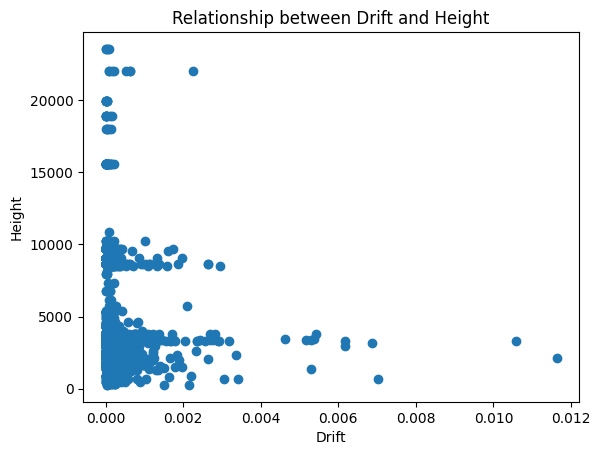

The covariance value between Drift and Height is -0.0031610150835036667 



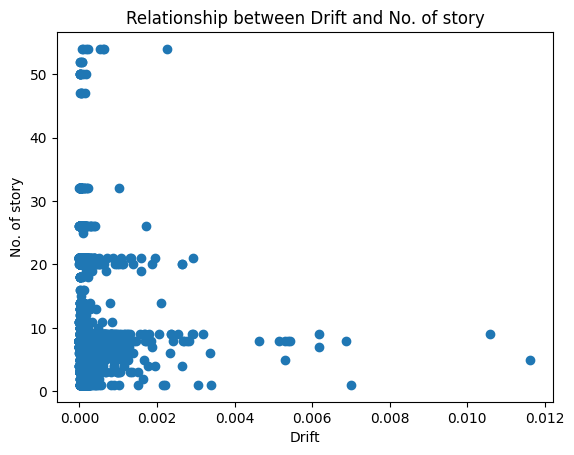

The covariance value between Drift and No. of story is 3.846005572870431e-06 



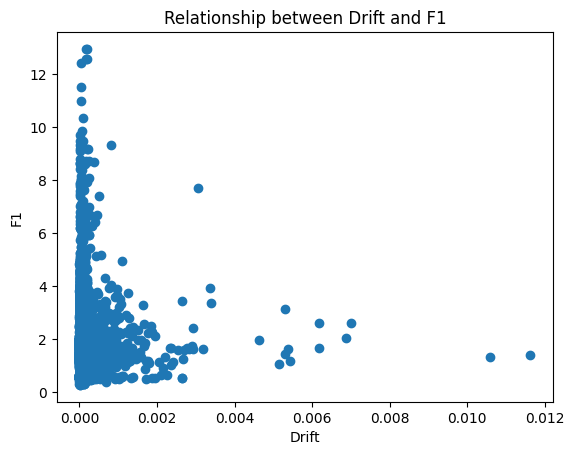

The covariance value between Drift and F1 is 3.939451161094179e-06 



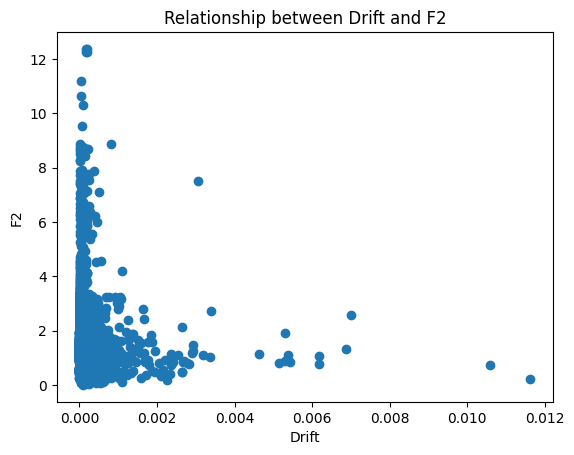

The covariance value between Drift and F2 is -1.7378599338794603e-06 



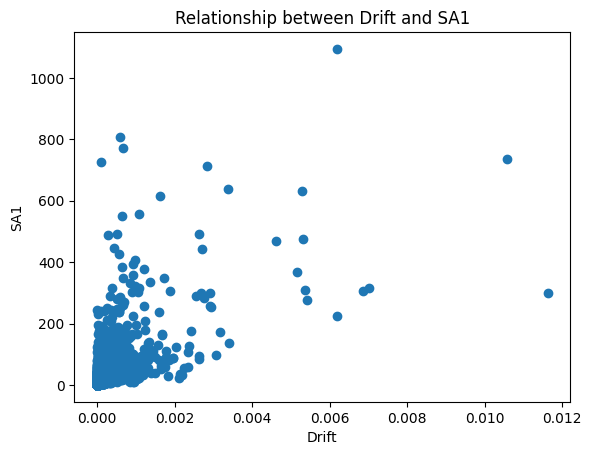

The covariance value between Drift and SA1 is 0.006193796617737247 



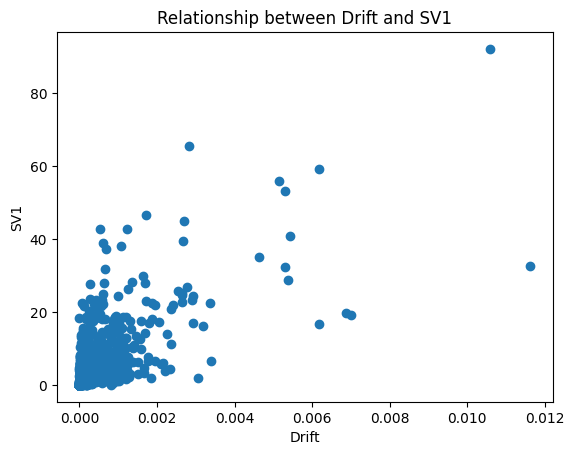

The covariance value between Drift and SV1 is 0.0005562216693313826 



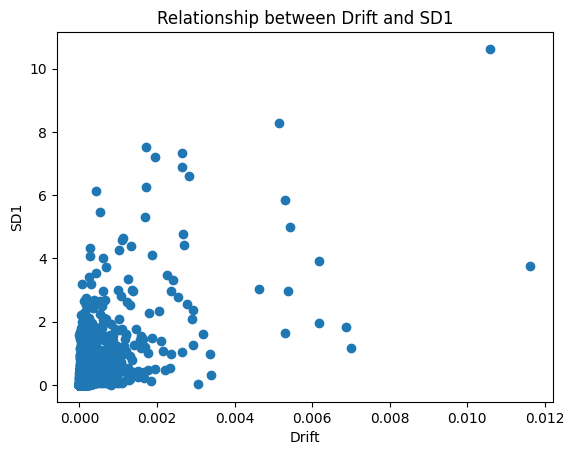

The covariance value between Drift and SD1 is 6.316617619841371e-05 



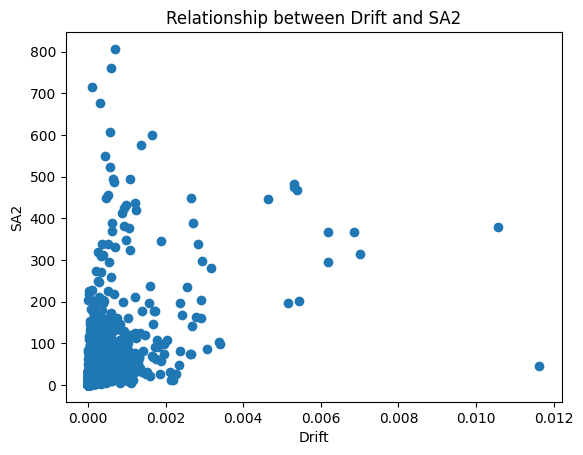

The covariance value between Drift and SA2 is 0.004881879589735317 



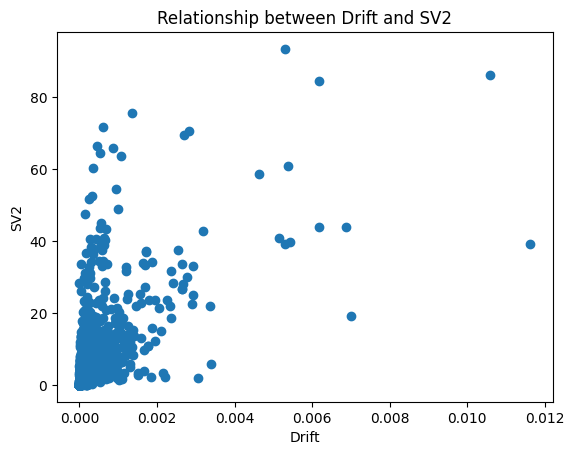

The covariance value between Drift and SV2 is 0.0007472079629579382 



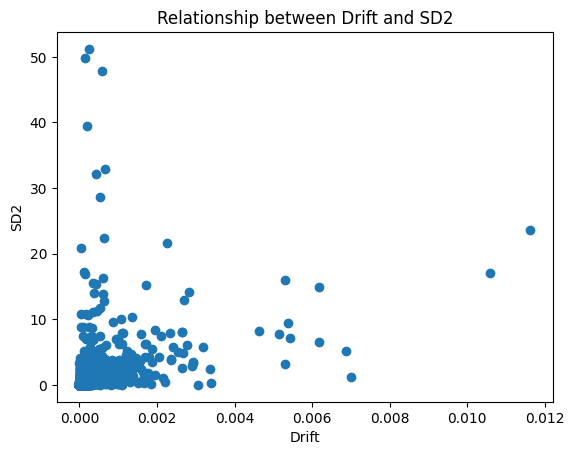

The covariance value between Drift and SD2 is 0.00015240437931943806 



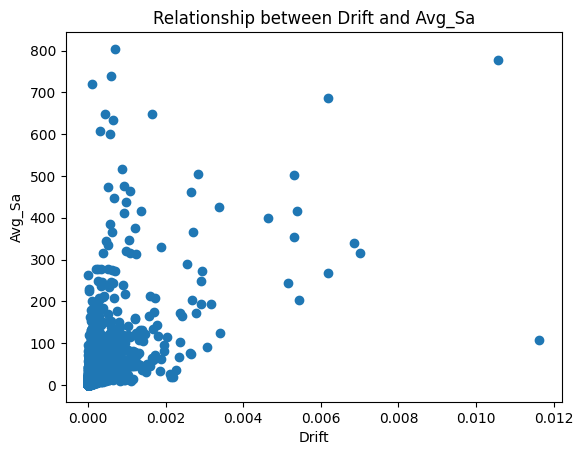

The covariance value between Drift and Avg_Sa is 0.005513256130964518 



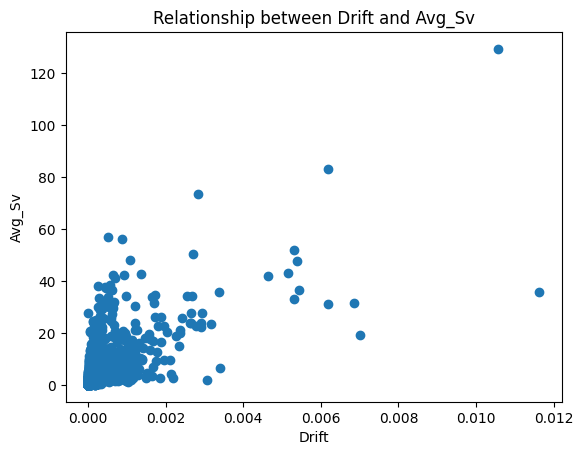

The covariance value between Drift and Avg_Sv is 0.0006781320212731939 



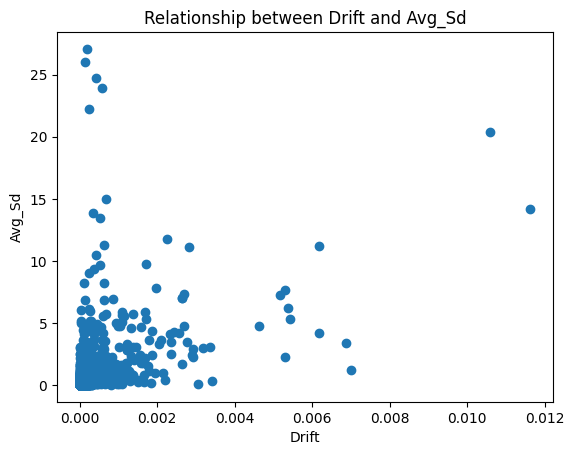

The covariance value between Drift and Avg_Sd is 0.00011080317011704754 



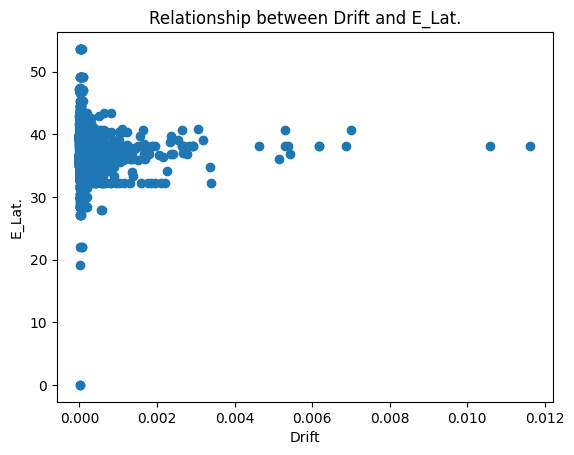

The covariance value between Drift and E_Lat. is 3.859116000689885e-06 



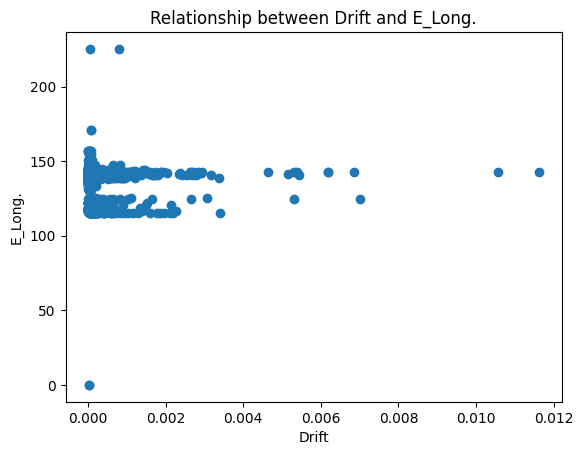

The covariance value between Drift and E_Long. is -0.000100010751709114 



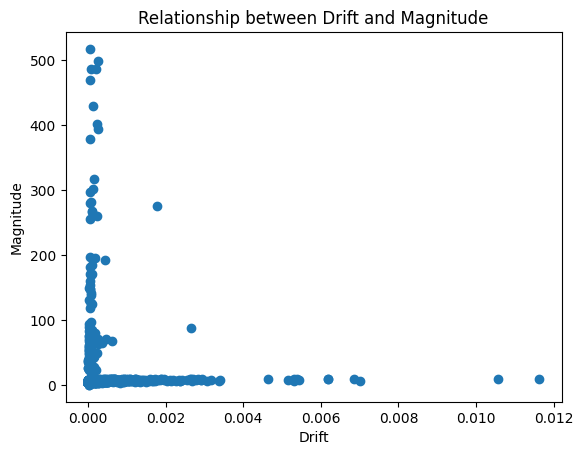

The covariance value between Drift and Magnitude is 0.0001771859177213588 



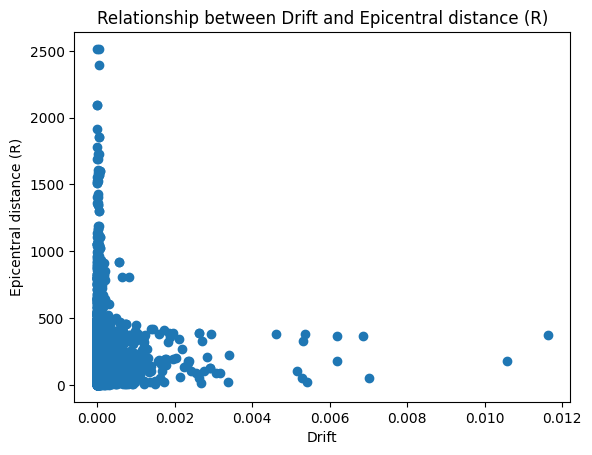

The covariance value between Drift and Epicentral distance (R) is 0.002258140615650594 



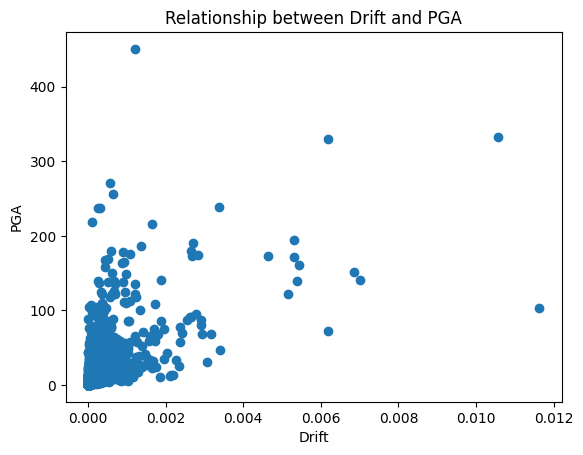

The covariance value between Drift and PGA is 0.0025377414161693278 



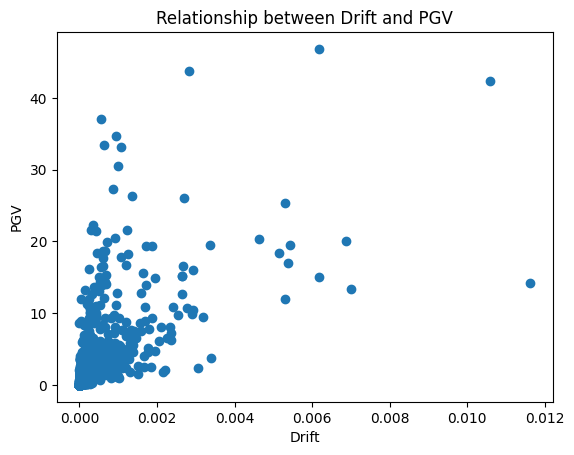

The covariance value between Drift and PGV is 0.00032297098483128044 



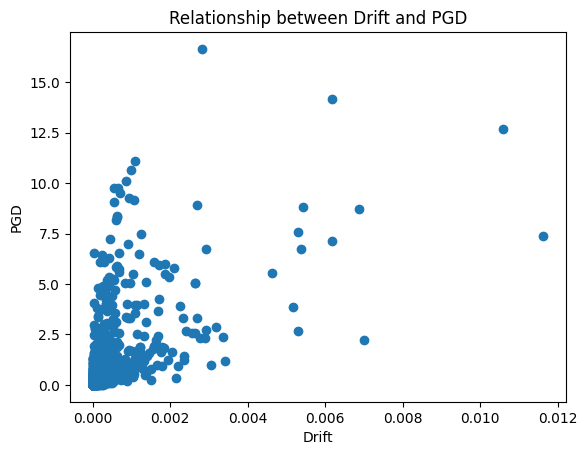

The covariance value between Drift and PGD is 0.00010422767111405986 



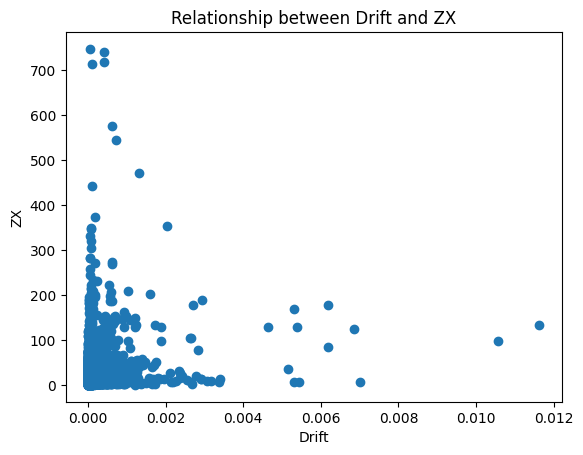

The covariance value between Drift and ZX is 0.0015126036332364584 



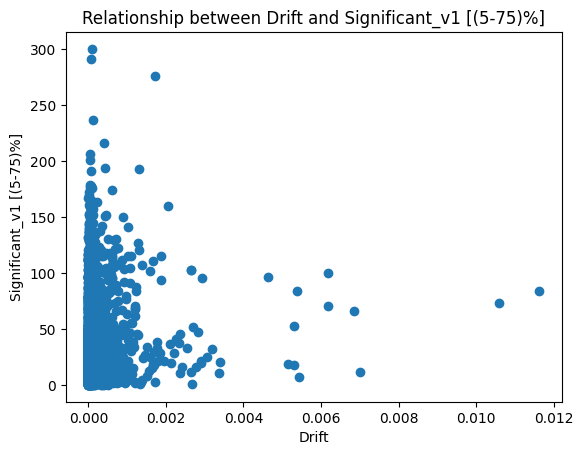

The covariance value between Drift and Significant_v1 [(5-75)%] is 0.0008032208180418209 



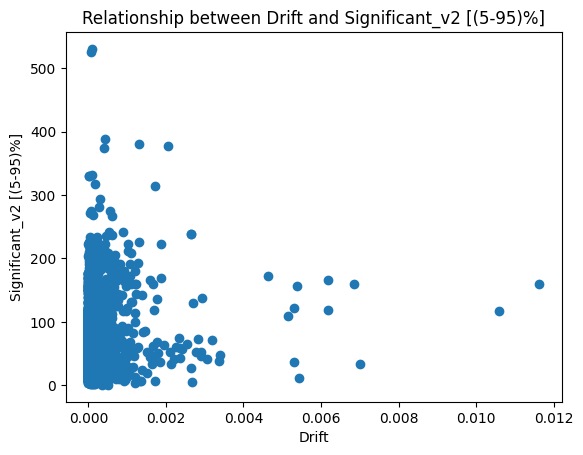

The covariance value between Drift and Significant_v2 [(5-95)%] is 0.0014425441385386246 



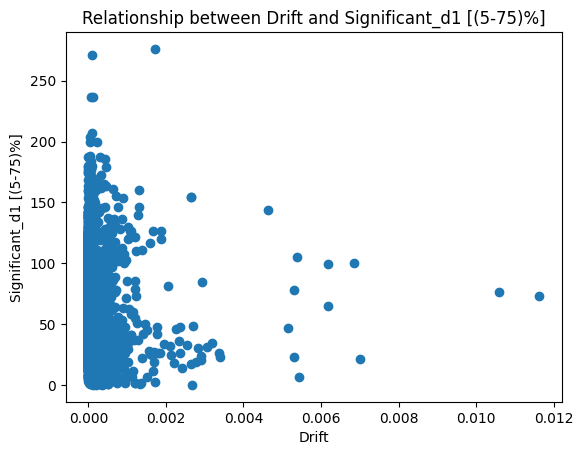

The covariance value between Drift and Significant_d1 [(5-75)%] is 0.0003366041378333866 



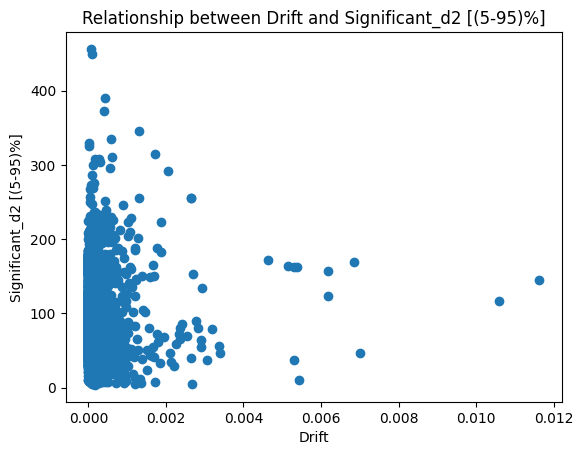

The covariance value between Drift and Significant_d2 [(5-95)%] is 0.0007838898966477601 



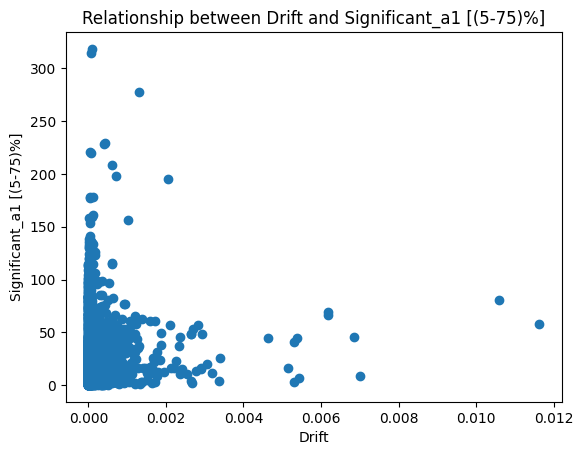

The covariance value between Drift and Significant_a1 [(5-75)%] is 0.0005116336725571237 



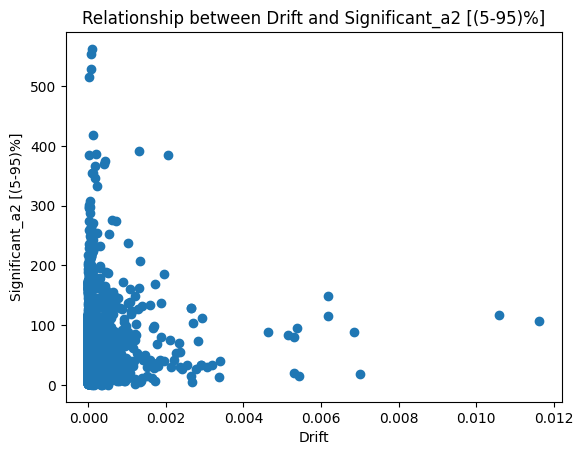

The covariance value between Drift and Significant_a2 [(5-95)%] is 0.0009754411774631447 



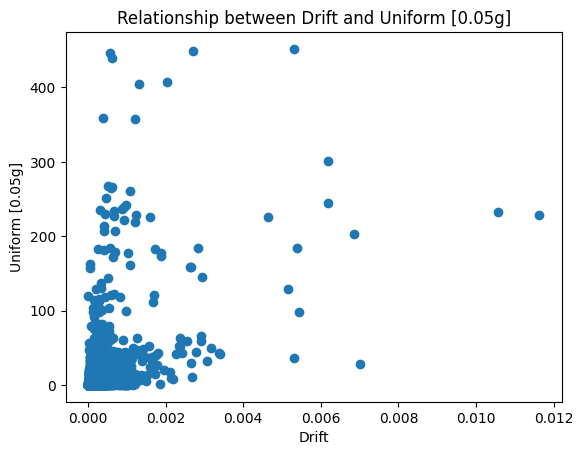

The covariance value between Drift and Uniform [0.05g] is 0.0027839586694113046 



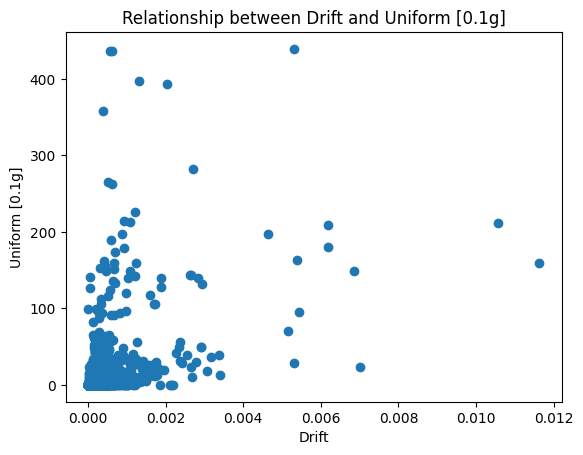

The covariance value between Drift and Uniform [0.1g] is 0.0021220229869797036 



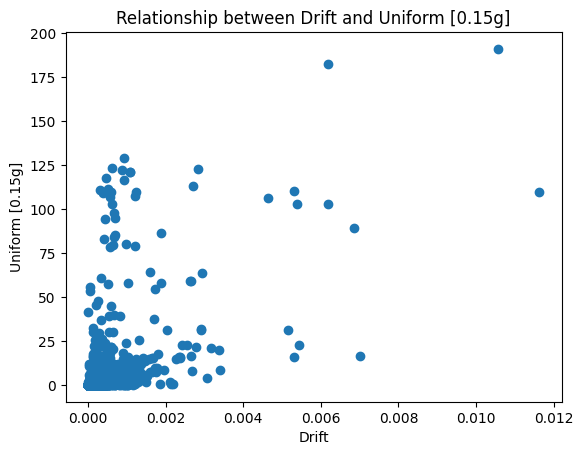

The covariance value between Drift and Uniform [0.15g] is 0.001116183961439575 



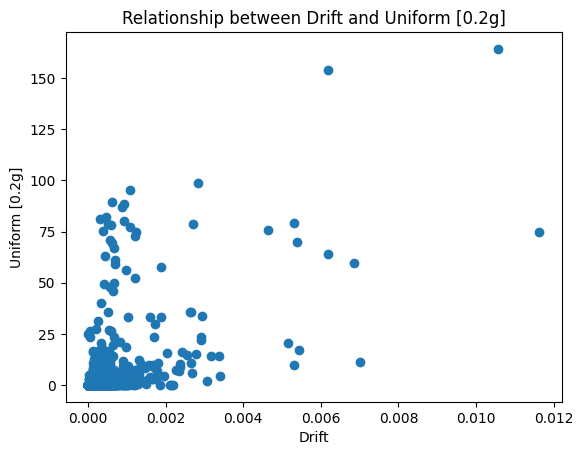

The covariance value between Drift and Uniform [0.2g] is 0.0007788981025561443 



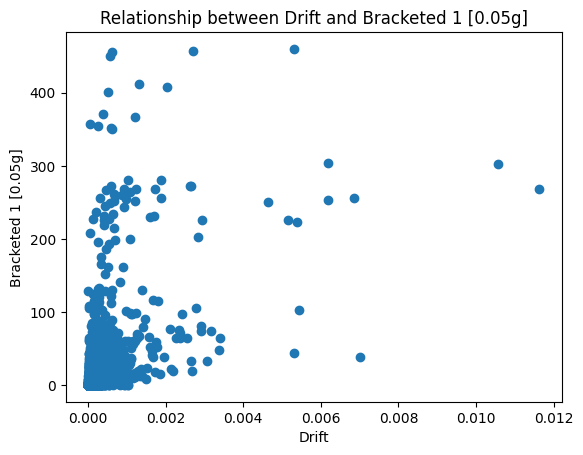

The covariance value between Drift and Bracketed 1 [0.05g] is 0.0035692961025142896 



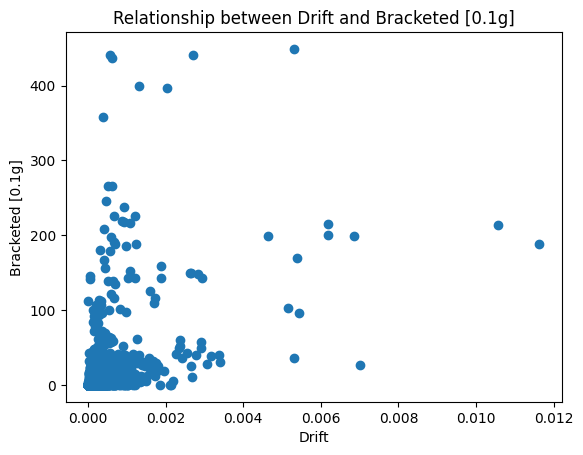

The covariance value between Drift and Bracketed [0.1g] is 0.0023807760091505313 



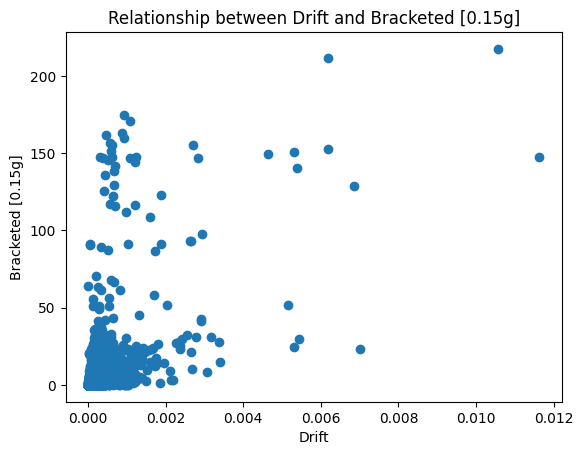

The covariance value between Drift and Bracketed [0.15g] is 0.0015559179944864493 



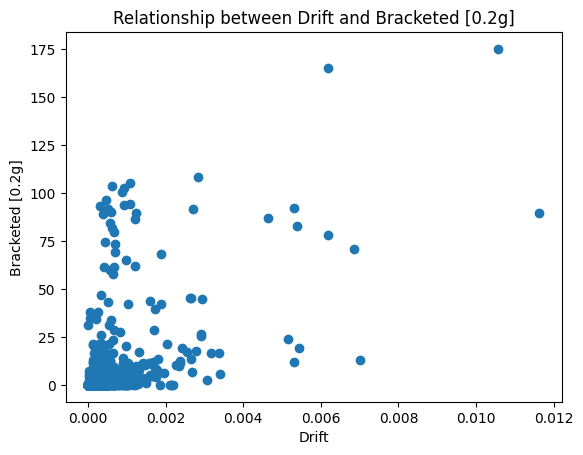

The covariance value between Drift and Bracketed [0.2g] is 0.0009081430461669746 



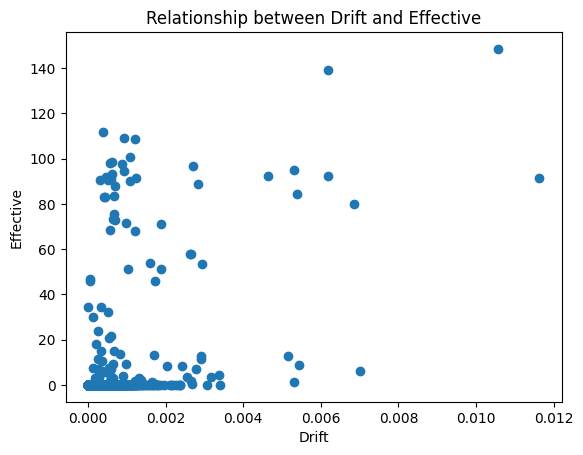

The covariance value between Drift and Effective is 0.0007764947812855436 



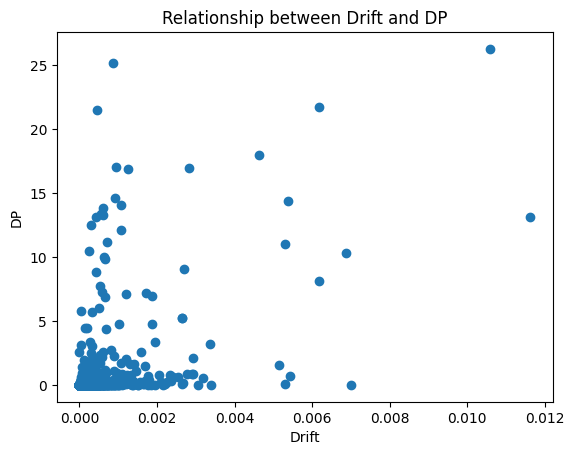

The covariance value between Drift and DP is 0.00010612142023291014 



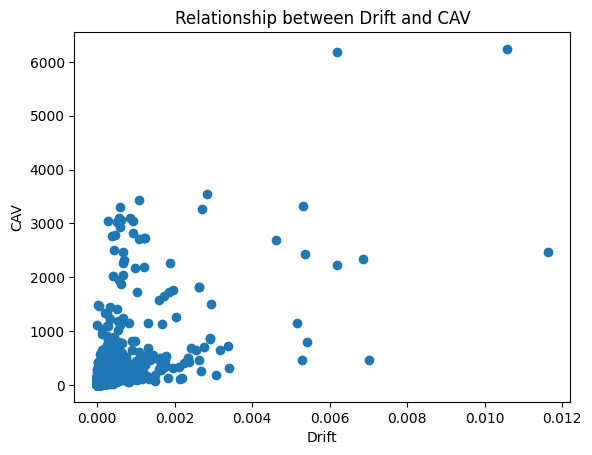

The covariance value between Drift and CAV is 0.032723447221847474 



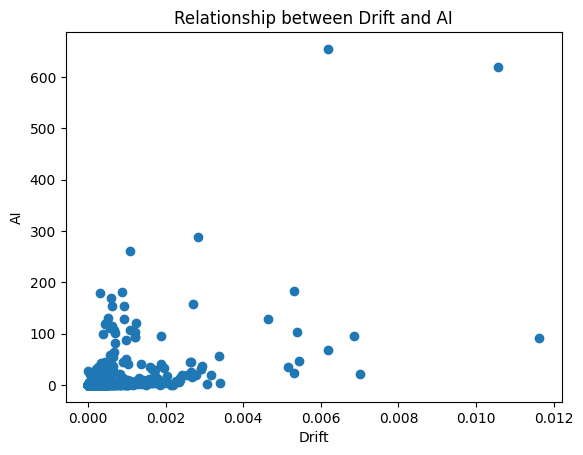

The covariance value between Drift and AI is 0.001721313677938971 



In [ ]:
# story height, story number, fortification intensity, longitudinal column distance and transverse span as inputs
# https://www.nature.com/articles/s41598-024-81705-3/tables/3

# histogram of drift in dataset
plt.figure(figsize=(8, 5))
sns.histplot(dataset["Drift"].dropna(), bins=50, kde=True)
plt.title("Distribution of Drift")
plt.xlabel("Drift")
plt.ylabel("Frequency")
plt.show()

# selecting 41 features in dataset (mentioned in reading)
X = dataset[['B_Lat.', # B_lat
                    'B_Long.',  # B_long
                    'Height',  # H
                    'No. of story',  # N
                    'F1',  # f1
                    'F2',  # f2
                    'SA1', # Sa1
                    'SV1',  # Sv1
                    'SD1', # Sd1
                    'SA2',  # Sa2
                    'SV2',  # Sv2
                    'SD2',  # Sd2
                    'Avg_Sa', # Avg_Sa
                    'Avg_Sv',  # Avg_Sv
                    'Avg_Sd', # Avg_Sd
                    'E_Lat.', # E_lat
                    'E_Long.', # E_long
                    'Magnitude',  # M
                    'Epicentral distance (R)',  # Dep
                    'PGA', # PGA
                    'PGV', # PGV
                    'PGD',
                    "ZX", #DZX
                    "Significant_v1 [(5-75)%]", #DSv1
                    "Significant_v2 [(5-95)%]", #DSv2
                    "Significant_d1 [(5-75)%]", #DSd1
                    "Significant_d2 [(5-95)%]", #DSd2
                    "Significant_a1 [(5-75)%]", #DSa1
                    "Significant_a2 [(5-95)%]", #DSa2
                    "Uniform [0.05g]", #DU1
                    "Uniform [0.1g]", #DU2
                    "Uniform [0.15g]", #DU3
                    "Uniform [0.2g]", #DU4
                    "Bracketed 1 [0.05g]", #DB1
                    "Bracketed [0.1g]", #DB2
                    "Bracketed [0.15g]", #DB3
                    "Bracketed [0.2g]", #DB4
                    "Effective", #DE
                    "DP", #DP
                    "CAV", #CAV
                    "AI", #la
                  ]]

# mapping covariance to drift for all features in X
covariance_features_dict = {}

for feature in X:
  plt.scatter(dataset['Drift'], dataset[feature])
  plt.title(f"Relationship between Drift and {feature}")
  plt.xlabel("Drift")
  plt.ylabel(f"{feature}")
  plt.show()

  cov_value = dataset[['Drift', feature]].cov().iloc[0,1]
  covariance_features_dict[feature] = cov_value
  print(f"The covariance value between Drift and {feature} is {cov_value} \n" )


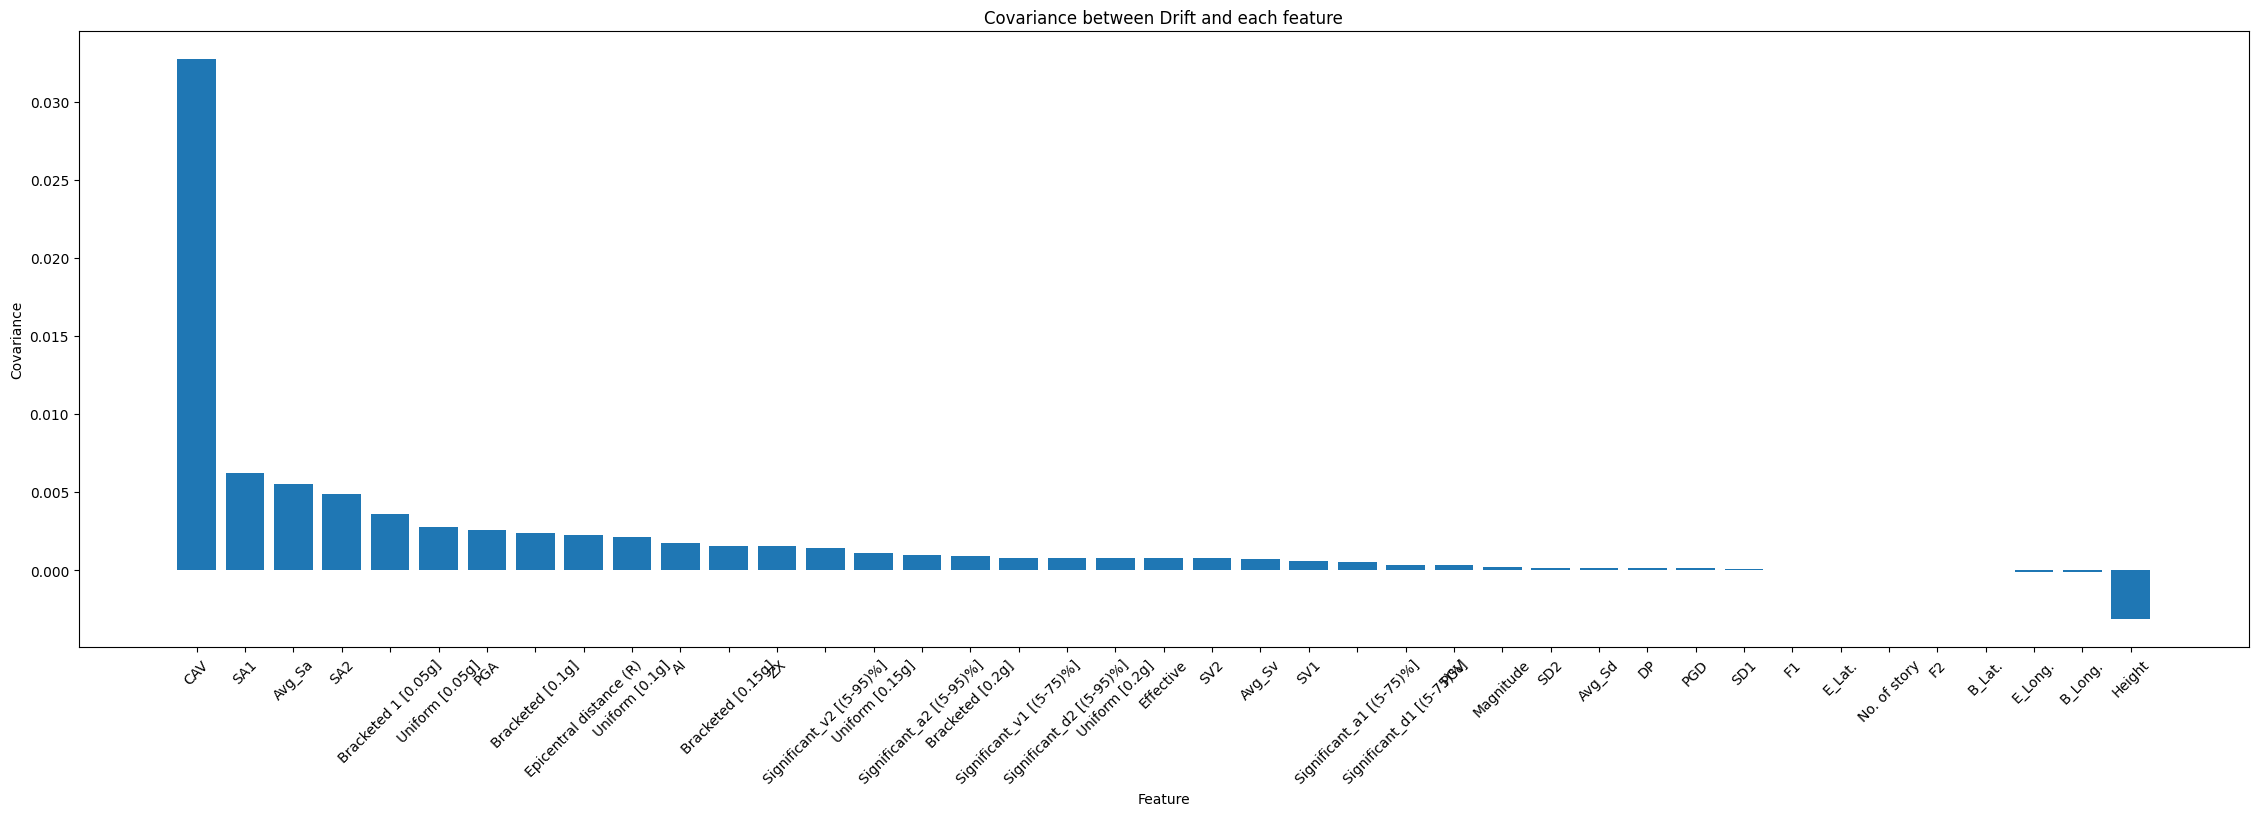

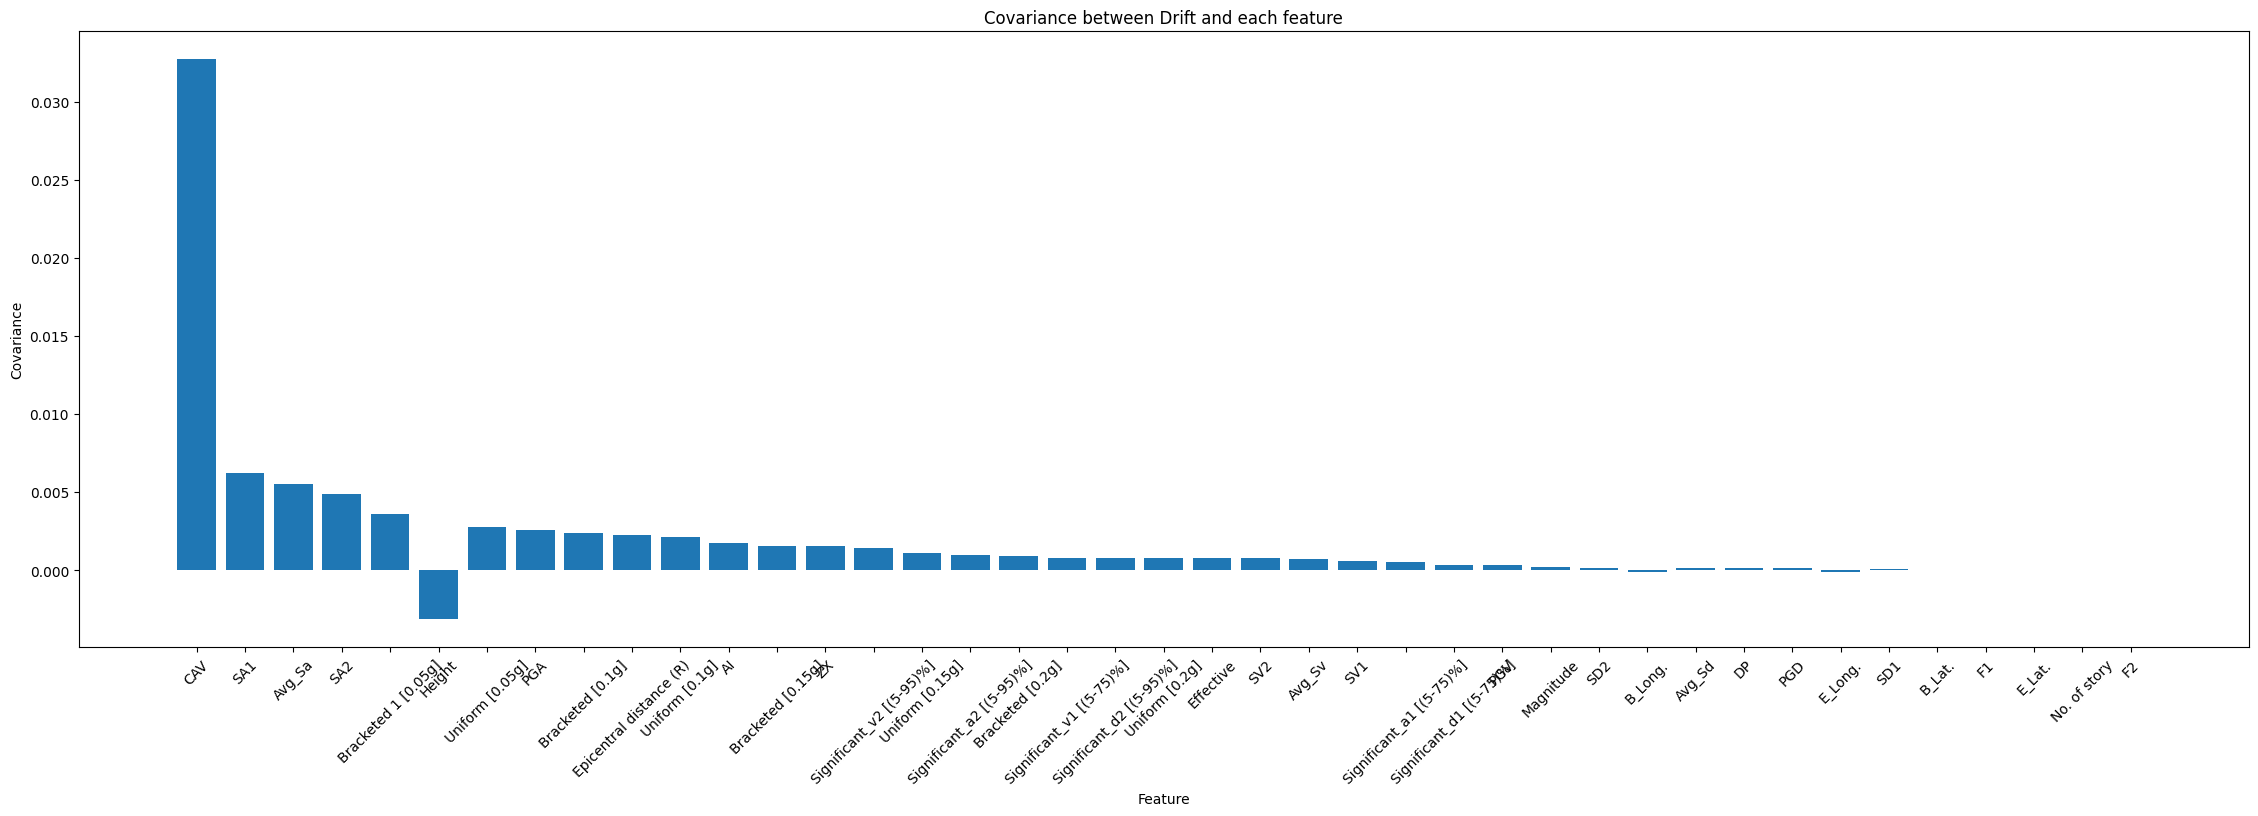

In [ ]:
sorted_items = sorted(covariance_features_dict.items(), key=lambda x: x[1], reverse=True)
features, cov_values = zip(*sorted_items)

# plain mapping of descending values (negatives being less than all positives)
plt.figure(figsize=(28, 8))
plt.bar(features, cov_values)
plt.title("Covariance between Drift and each feature")
plt.xlabel("Feature")
plt.ylabel("Covariance")
plt.xticks(rotation=45)
plt.show()

# with maintaining negative values (absolute values) instead of negatives beeing less than positives
sorted_items = sorted(covariance_features_dict.items(), key=lambda x: abs(x[1]), reverse=True)
features, cov_values = zip(*sorted_items)

plt.figure(figsize=(28, 8))
plt.bar(features, cov_values)
plt.title("Covariance between Drift and each feature")
plt.xlabel("Feature")
plt.ylabel("Covariance")
plt.xticks(rotation=45)
plt.show()

c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift? (Kayla)

The visualization bar plotted the covariance of each of the 41 features in relation to the Drift variable. Based on this visualization ordered by greatest to least covariance, **CAV, SA1, Avg_Sa, and SA2** are potentially the most influential in predicting Drfit. CAV is especially influential with a covariance over 0.030, while the rest remained under 0.010.

A pattern I see is that the SA variables (SA1, SA2, Avg_Sa) appear to have much impact on the Drift prediction. Following the SA variables, Bracketed variables followed, then many of the V variables (v2, v1, etc.). Further right in the graph, the SD variables (SD2, Avg_Sd, SD1, etc.) appeared. Other variables that were more individual scattered towards the end as well.

CAV's covariance is substantially higher than that of the other 40 features. It may dominate in prediction later on when fitting and predicting models. With that logic, SD and story features may be less influential compared to the other features due to the lesser covariances with drift. This doesn't mean that they "don't matter" in the prediction's influence, however.

## 3. Fit and test (30 points) (Kayla)

a. Fit and test a SVR model using all available features. This process should include an automatic tuning of both the kernel and the penalty term (C). Evaluate the model using at least Coefficient of determination (R²) and Mean Squared Error (MSE). (Kayla)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

feature_cols = [
    'B_Lat.', # B_lat
    'B_Long.',  # B_long
    'Height',  # H
    'No. of story',  # N
    'F1',  # f1
    'F2',  # f2
    'SA1', # Sa1
    'SV1',  # Sv1
    'SD1', # Sd1
    'SA2',  # Sa2
    'SV2',  # Sv2
    'SD2',  # Sd2
    'Avg_Sa', # Avg_Sa
    'Avg_Sv',  # Avg_Sv
    'Avg_Sd', # Avg_Sd
    'E_Lat.', # E_lat
    'E_Long.', # E_long
    'Magnitude',  # M
    'Epicentral distance (R)',  # Dep
    'PGA', # PGA
    'PGV', # PGV
    'PGD',
    "ZX", #DZX
    "Significant_v1 [(5-75)%]", #DSv1
    "Significant_v2 [(5-95)%]", #DSv2
    "Significant_d1 [(5-75)%]", #DSd1
    "Significant_d2 [(5-95)%]", #DSd2
    "Significant_a1 [(5-75)%]", #DSa1
    "Significant_a2 [(5-95)%]", #DSa2
    "Uniform [0.05g]", #DU1
    "Uniform [0.1g]", #DU2
    "Uniform [0.15g]", #DU3
    "Uniform [0.2g]", #DU4
    "Bracketed 1 [0.05g]", #DB1
    "Bracketed [0.1g]", #DB2
    "Bracketed [0.15g]", #DB3
    "Bracketed [0.2g]", #DB4
    "Effective", #DE
    "DP", #DP
    "CAV", #CAV
    "AI", #la
]

df = dataset.dropna(subset=['Drift']).copy()
X = df[feature_cols].apply(pd.to_numeric, errors='coerce')
y = df['Drift']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 30)

scaler = StandardScaler()
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

In [ ]:
# X.isna().sum()

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import TransformedTargetRegressor

pipeline_svr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

cv_svr = KFold(n_splits=3, shuffle=True, random_state=42)

param_grid_svr = {
    "svr__kernel": ["linear", "rbf"],#, "poly", "sigmoid"],
    "svr__C": [0.1, 1, 10, 100],
    #"svr__gamma": ["scale", "auto"],
}

grid_svr = GridSearchCV(pipeline_svr, param_grid=param_grid_svr, cv=cv_svr, scoring="r2", n_jobs=-1)
grid_svr.fit(X_train, y_train_scaled)

GridSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('svr', SVR())]),
             n_jobs=-1,
             param_grid={'svr__C': [0.1, 1, 10, 100],
                         'svr__kernel': ['linear', 'rbf']},
             scoring='r2')

In [ ]:
best_model_svr = grid_svr.best_estimator_
y_pred_svr = best_model_svr.predict(X_test)
y_pred_svr = scaler.inverse_transform(y_pred_svr.reshape(-1, 1)).ravel()

r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
print(f"r2: {r2_svr}")
print(f"MSE: {mse_svr}")

r2: 0.23368445415389838
MSE: 5.6315406008903046e-08


In [ ]:
best_params = grid_svr.best_params_
print(best_params)

{'svr__C': 0.1, 'svr__kernel': 'linear'}


b. Repeat the previous process using an Ridge linear regression model. Be sure to include automatic tuning of the model’s hyperparameters, specifically, `alpha`. (Kayla)

In [ ]:
from sklearn.linear_model import Ridge

x_pipe_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid_ridge = {
    "ridge__alpha": [0.1, 1, 10, 100]
}

cv_ridge = KFold(n_splits=3, shuffle=True, random_state=42)

grid_ridge = GridSearchCV(estimator=x_pipe_ridge, param_grid=param_grid_ridge, cv=cv_ridge, scoring="r2", n_jobs=-1)
grid_ridge.fit(X_train, y_train)

best_model_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_model_ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"r2: {r2_ridge}")
print(f"MSE: {mse_ridge}")

r2: 0.3060837510266312
MSE: 5.0994887822565906e-08


In [ ]:
print("Best alpha:", grid_ridge.best_params_)

Best alpha: {'ridge__alpha': 100}


c. Use predicted vs. true value scatterplots to compare the SVR and Ridge models. Embed performance metrics (e.g., R², MSE) in each plot.

Which model seems to perform better at this task? (Kayla)

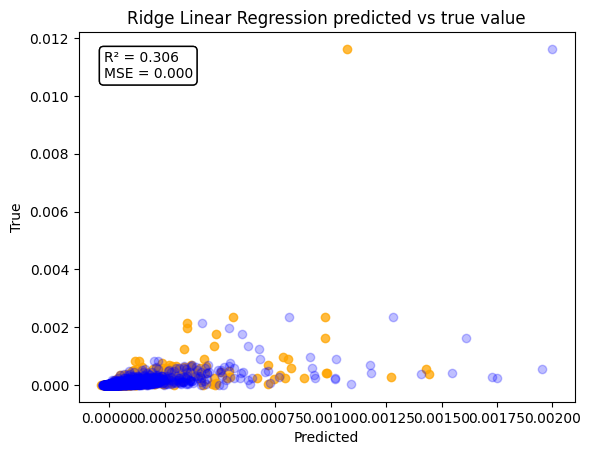

In [ ]:
# SVR
plt.scatter(y_pred_svr, y_test, color="orange", alpha=0.75)
plt.title("SVR predicted vs true value")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.text(0.05, 0.95, f"R² = {r2_svr:.3f}\nMSE = {mse_svr:.3f}",
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle="round", fc="w"))
# plt.show()

# Ridge Linear Regression
plt.scatter(y_pred_ridge, y_test, color="blue", alpha=0.25)
plt.title("Ridge Linear Regression predicted vs true value")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.text(0.05, 0.95, f"R² = {r2_ridge:.3f}\nMSE = {mse_ridge:.3f}",
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle="round", fc="w"))

plt.show()

It seems the ridge regression model performed better than the SVR model based on the performance aligning between the y_predicted to the y actual. The lower MSE and higher R^2 scores also backup this claim based on the graphs. So even though the optimized SVR model is designed to capture non-linear relationships, the ridge regression model performed better.

This may provide evidence that the relationship between the drift and features is more linear than once thought.

## 4. Reduced SVR Model (30 points) (Mason)

a. Include a feature selection step in the SVR pipeline that selects the 10 features most correlated with Drift. Retrain and evaluate the model after this step.

In [ ]:
# [Your code here]

# Build new pipeline that adds feature selection step
# Insert best SVR parameters found in Gridsearch above
ft_selection = SelectKBest(score_func=f_regression, k=10)
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
svr = SVR(kernel = 'linear', C=0.1)
steps = [('imputer', imputer), ('feature_selection', ft_selection), ('scaler', scaler), ('svr', svr)]
pipeline_3 = Pipeline(steps)

# Scale the output variable
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

# Retrain model
pipeline_3.fit(X_train, y_train_scaled)

# Evaluate model
y_pred = pipeline_3.predict(X_test)
r2 = r2_score(y_test_scaled, y_pred)
mse = mean_squared_error(y_test_scaled, y_pred)

print("R2:", r2)
print("MSE", mse)

R2: 0.281970013261554
MSE 0.673178870383227


Subsequently, answer the following questions:

- How much does the performance change?
- What are the practical advantages of this smaller model?

Elaborate on your answers.

This model performed relatively on par with the models above. It did not score better than the Ridge model, but it performed better than the original SVR model. The small MSE is still an indicator that this version of the model is overfitting the data.

Practical advantages of the smaller model are that it takes less computing power and time to make predictions. It also can remove noisy variables from the data that have little predictive power over the target variable. It also creates ease of model interpretation since only the most important features are included.

b. Compare the performance of this reduced-feature pipeline with a Lasso regression model using all features.
- Do both models select the same features?
- How do their performances compare?

In [ ]:
# Create a pipeline for Lasso regression
lasso = Lasso(alpha=0.001)
lr_steps = [('imputer', imputer),  ('scaler', scaler), ('lasso', lasso)]
pipeline_4 = Pipeline(lr_steps)

# Train with the Lasso regression model
pipeline_4.fit(X_train, y_train_scaled)

# Evaluate model
y_pred = pipeline_4.predict(X_test)
r2 = r2_score(y_test_scaled, y_pred)
mse = mean_squared_error(y_test_scaled, y_pred)

print("R2:", r2)
print("MSE", mse)

R2: 0.2949410638210239
MSE 0.6610180451745601


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.652e+01, tolerance: 1.000e+00
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# Evaluate the most important features selected by Lasso Regression
features = X_train.columns
coefficients = pipeline_4.named_steps["lasso"].coef_

feature_importance = pd.DataFrame({"Feature": features, "Coefficient": abs(coefficients)})

features_top_10 = feature_importance.sort_values(by='Coefficient', ascending=False).head(10)

# Print the top 10 features used by Lasso
print("Lasso Top 10 Features:\n", features_top_10)

Lasso Top 10 Features:
               Feature  Coefficient
13             Avg_Sv     0.531317
36   Bracketed [0.2g]     0.401767
35  Bracketed [0.15g]     0.373202
40                 AI     0.268220
12             Avg_Sa     0.246676
7                 SV1     0.234928
21                PGD     0.223225
39                CAV     0.162476
8                 SD1     0.116916
6                 SA1     0.113249


In [ ]:
# Evaluate the features selected by SelectKBest in the SVR pipeline
selected_features_mask = pipeline_3.named_steps['feature_selection'].get_support()

svr_top_10_features = X_train.columns[selected_features_mask].tolist()

# Print the top 10 features used by SVR
print("SVR Top 10 Features:\n")
for f in svr_top_10_features:
  print(f)

SVR Top 10 Features:

SA1
SV1
SD1
SV2
Avg_Sa
Avg_Sv
PGA
PGV
PGD
CAV


The Lasso Regression model performed just slightly better than the SVR model with feature selection. The $R^2$ is slightly greater and the mse is smaller. Overall, their performances are very similar.

In terms of feature selection, these models selected a decent amount of features in common. Overlapping features selected in both instances include: Avg_Sa, Avg_Sv, CAV, PGD, SA1. These common features indicate that each model emphasized similar variables as being most relevant for prediction.

## 5: Robustness to Point Removal (10 points) (DJ)

a. Compare the sensitivity of SVR and Ridge Regression to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both models, and observe how much the predictions change.
- Which model appears more stable?
- Why?



In [ ]:
def prediction_change(y_full, y_reduced):
  return np.mean((y_full - y_reduced)**2)

best_model_svr.fit(X_train, y_train_scaled)
y_pred_svr_full = best_model_svr.predict(X_test)

best_model_ridge.fit(X_train, y_train)
y_pred_ridge_full = best_model_ridge.predict(X_test)

random_number = np.random.default_rng(42)
remove_index = random_number.choice(len(X_train), size=10, replace=False)
mask = np.ones(len(X_train), dtype=bool) #True and Falses, Sensitivity = False Negative
mask[remove_index] = False

X_train_reduced = X_train[mask]
y_train_reduced_svr = y_train_scaled[mask]
y_train_reduced_ridge = y_train[mask]

best_model_svr.fit(X_train_reduced, y_train_reduced_svr)
y_pred_svr_reduced = best_model_svr.predict(X_test)

best_model_ridge.fit(X_train_reduced, y_train_reduced_ridge)
y_pred_ridge_reduced = best_model_ridge.predict(X_test)

svr_shift = prediction_change(y_pred_svr_full, y_pred_svr_reduced) / np.var(y_pred_svr_full)
ridge_shift = prediction_change(y_pred_ridge_full, y_pred_ridge_reduced) / np.var(y_pred_ridge_full)

print("SVR prediction shift:   ", svr_shift)
print("Ridge prediction shift: ", ridge_shift)


SVR prediction shift:    1.1627874663284535e-05
Ridge prediction shift:  4.871236251017629e-07


Ridge Regression appears to be more stable and is less sensitive to small data changes because it penalizes large coefficients(shrinking them to zero), which reduces overall model variance. SVR in the other hand, focuses on errors beyond a certain threshold, near the epsilon margin, so they are more sensitive to individual data points. Therefore the predictions can shift more.

## 6. Collaboration Reflection (5 points)

As a group, briefly reflect on the following (max 1–2 short paragraphs):

- How did the group dynamics work throughout the assignment?
- Were there any major disagreements or diverging approaches?
- How did you resolve conflicts or make final modeling decisions?
- What did you learn from each other during this project?

Unlike other weeks, we had a huge project that was due on Monday, which led us to start late. We didn't make any significant progress before this weekend, but we stood up starting this monday. There weren't major disagreements, but there were some technical issues. My computer took a long time to go through the grid search in Part 3, so I suggested if we can change the number of cross validation from 5 to 3. Reducing the number of cross validation reduced the time for my code to run, so we were able to work more efficiently. We resolved conflicts by asking the professor about questions or codes that we are stuck. Completing three projects with this group, we are learning more about each other's style of code.